## Radial Velocity Analysis of the 55 Cancri Planetary System
Howard, Andrew W. ; Fulton, Benjamin J. 

In [12]:
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt("274RVC_.txt", comments="\\", skip_header=22)
time = data[:,0]
rv = data[:,1]   
rv_err = data[:,2]

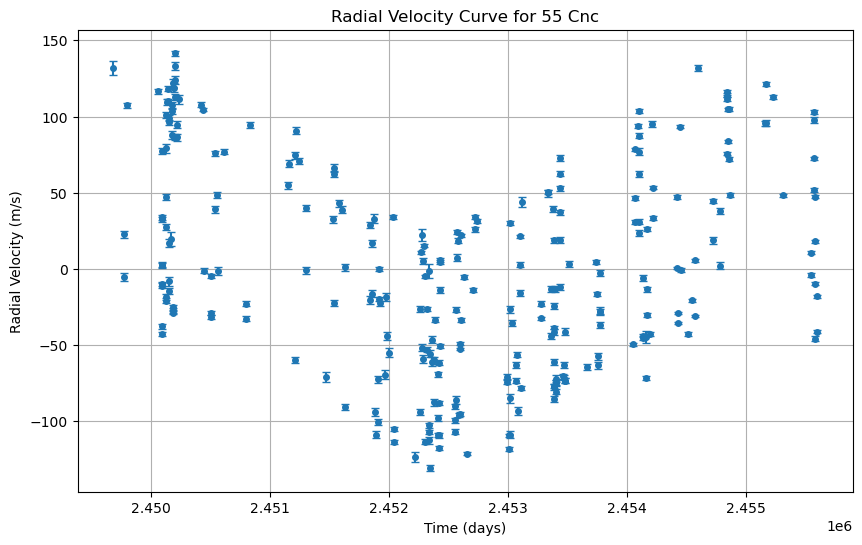

In [13]:
plt.figure(figsize=(10,6))
plt.errorbar(time, rv, yerr=rv_err, fmt='o', markersize=4, capsize=3)
plt.xlabel("Time (days)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity Curve for 55 Cnc")
plt.grid()
plt.show()

In [14]:
from scipy.optimize import curve_fit

def rv_model(t, K, P, phi, C):
    return K * np.sin(2*np.pi*t/P + phi) + C

# Initial guesses
initial_guess = [50, 15, 0, 0]

popt, pcov = curve_fit(rv_model, time, rv, p0=initial_guess)

K_fit, P_fit, phi_fit, C_fit = popt

print("Best Fit Parameters:")
print("K =", K_fit, "m/s")
print("P =", P_fit, "days")

Best Fit Parameters:
K = -11.640601019107889 m/s
P = 14.986373079694589 days


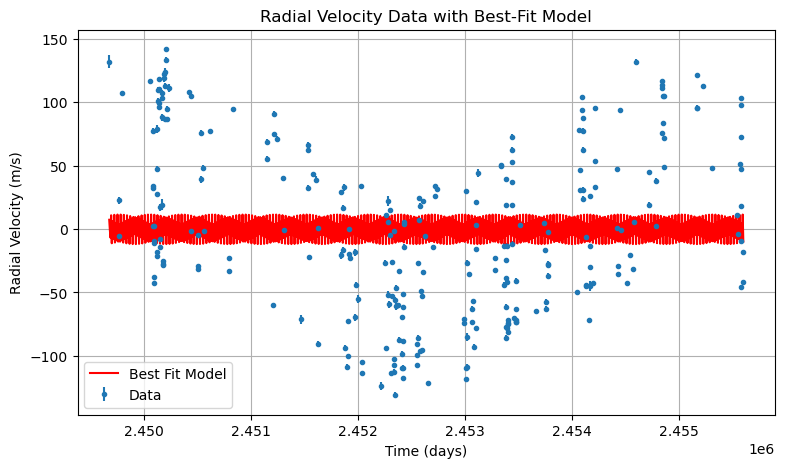

In [15]:
t_fit = np.linspace(min(time), max(time), 1000)
rv_fit = rv_model(t_fit, K_fit, P_fit, phi_fit, C_fit)

plt.figure(figsize=(9,5))
plt.errorbar(time, rv, yerr=rv_err, fmt='o', markersize=3, label="Data")
plt.plot(t_fit, rv_fit, 'r', label="Best Fit Model")
plt.xlabel("Time (days)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity Data with Best-Fit Model")
plt.legend()
plt.grid()
plt.show()

# subtract

In [16]:
rv_model_data = rv_model(time, K_fit, P_fit, phi_fit, C_fit)
residuals = rv - rv_model_data

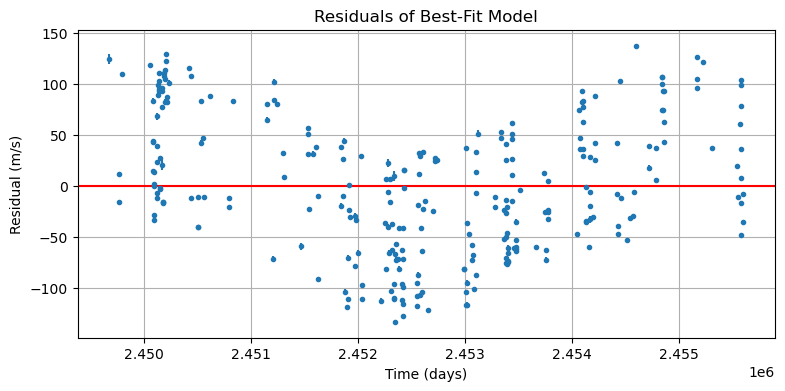

In [17]:
plt.figure(figsize=(9,4))
plt.errorbar(time, residuals, yerr=rv_err, fmt='o', markersize=3)
plt.axhline(0, color='red')
plt.xlabel("Time (days)")
plt.ylabel("Residual (m/s)")
plt.title("Residuals of Best-Fit Model")
plt.grid()
plt.show()

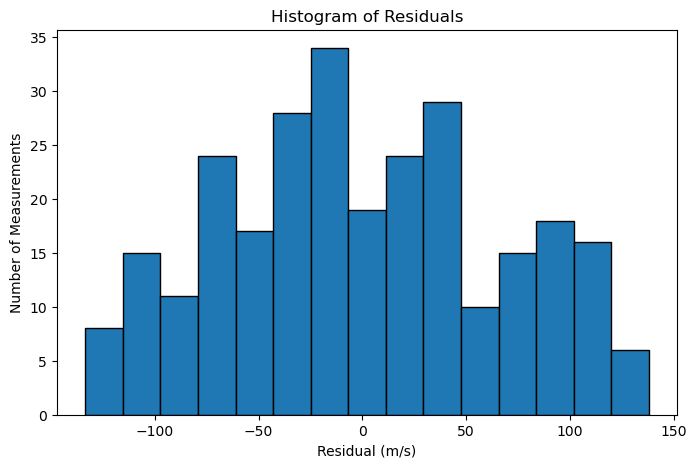

In [18]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=15, edgecolor='black')
plt.xlabel("Residual (m/s)")
plt.ylabel("Number of Measurements")
plt.title("Histogram of Residuals")
plt.show()

In [19]:
std_residuals = np.std(residuals)
mean_error = np.mean(rv_err)

print("Standard deviation of residuals =", std_residuals, "m/s")
print("Average experimental uncertainty =", mean_error, "m/s")

Standard deviation of residuals = 66.51059199728103 m/s
Average experimental uncertainty = 1.8060667343065693 m/s


In [20]:
M_star = 0.91  # solar masses

M_planet = (abs(K_fit)/28.4) * (P_fit/365)**(1/3) * (M_star)**(2/3)

print("Planet mass =", M_planet, "M_Jupiter")

Planet mass = 0.1327860801636063 M_Jupiter


Planet name is K2-274 b